### 1. Distribution Science
**Author:** Saicharan k

#### Goal
Understand the underlying shape and spread of the data. 

**Key Questions:**
1. Is the salary distribution Normal (Gaussian) or Skewed?
2. Are there significant outliers in the global market?
3. How is the talent pool distributed across Experience and Job Roles?

**Metric Focus:**
- **Univariate Analysis:** Histograms, Boxplots, Countplots.
- **Descriptive Stats:** Skewness, Kurtosis.

In [1]:
# empty cell

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


df = pd.read_csv('../data/ds_salaries_cleaned.csv')

print(f"Loaded Clean Data: {df.shape}")
print('\n\n\n')
display(df.head())

Loaded Clean Data: (565, 13)






,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category,salary_band
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L,Data Scientist,junior(60k - 100k)
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S,Machine Learning Engineer,Elite(250k>)
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M,Data Engineer,MId(100k - 150k)
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S,Data Analyst,Entry(<60k)
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L,Machine Learning Engineer,MId(100k - 150k)


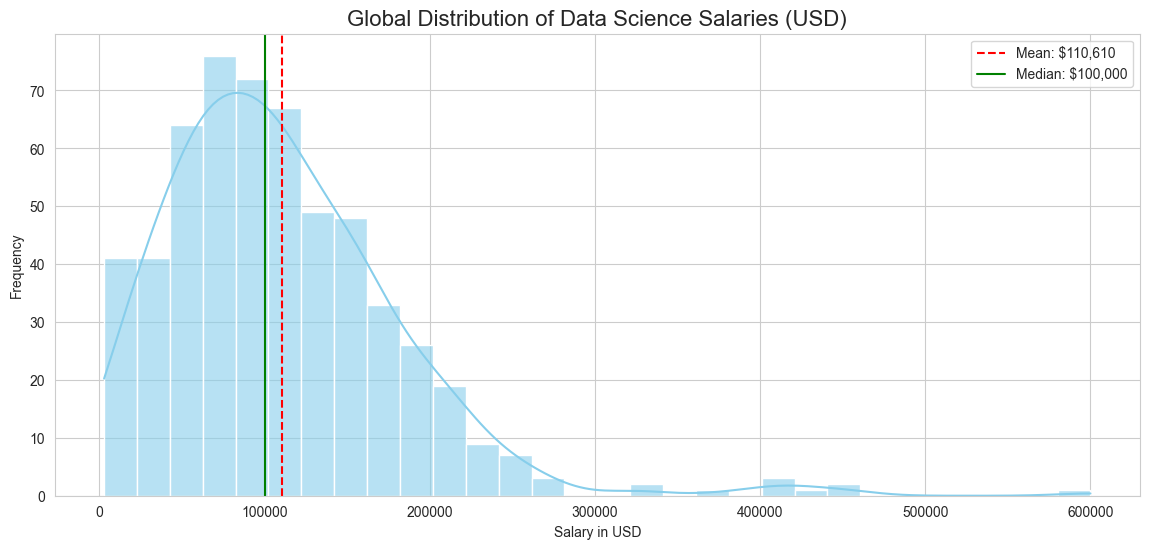

Skewness: 1.73
Interpretation: Highly Right-Skewed (Long tail of high earners).


In [4]:
#  set up the figure
plt.figure(figsize=(14, 6))

#  plot histogram with KDE (Kernel Density Estimate)
sns.histplot(df['salary_in_usd'], kde=True, color='skyblue', bins=30, alpha=0.6)

#  add lines for mean and median
plt.axvline(df['salary_in_usd'].mean(), color='red', linestyle='--', label=f"Mean: ${df['salary_in_usd'].mean():,.0f}")
plt.axvline(df['salary_in_usd'].median(), color='green', linestyle='-', label=f"Median: ${df['salary_in_usd'].median():,.0f}")

#  formatting
plt.title('Global Distribution of Data Science Salaries (USD)', fontsize=16)
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#  skewness
skewness = df['salary_in_usd'].skew()
print(f"Skewness: {skewness:.2f}")
if skewness > 1:
    print("Interpretation: Highly Right-Skewed (Long tail of high earners).")
elif skewness > 0.5:
    print("Interpretation: Moderately Right-Skewed.")

In [ ]:
#empty cell

### 2. Outlier Detection
We use Boxplots to visually identify outliers. Points beyond the "whiskers" (usually 1.5 * IQR) represent anomalies—likely Executive roles or specific high-paying regions (e.g., San Francisco).

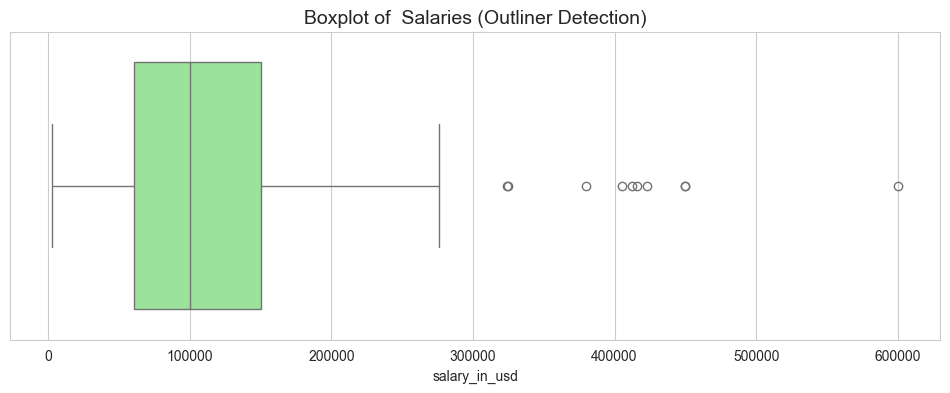

25th Percentile: $60,757
75th Percentile: $150,000
IQR (Middle 50% Spread): $89,243


In [11]:
plt.figure(figsize = (12,4))
sns.boxplot(x = df['salary_in_usd'], color='lightgreen')

plt.title('Boxplot of  Salaries (Outliner Detection)',fontsize = 14)
plt.xlabel =('Salary(USD)')
plt.show()

# Calculating the IQR (Interquartile Range) numerically
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
print(f"25th Percentile: ${Q1:,.0f}")
print(f"75th Percentile: ${Q3:,.0f}")
print(f"IQR (Middle 50% Spread): ${IQR:,.0f}")

In [ ]:
# empty cell

### 3. Categorical Distributions (Demographics)
Understanding the composition of our dataset is crucial for bias detection.
- **Experience:** Is the data dominated by Seniors?
- **Remote:** How prevalent is remote work in this dataset?
- **Company Size:** Are we looking at Startups (S) or Corporations (L)?

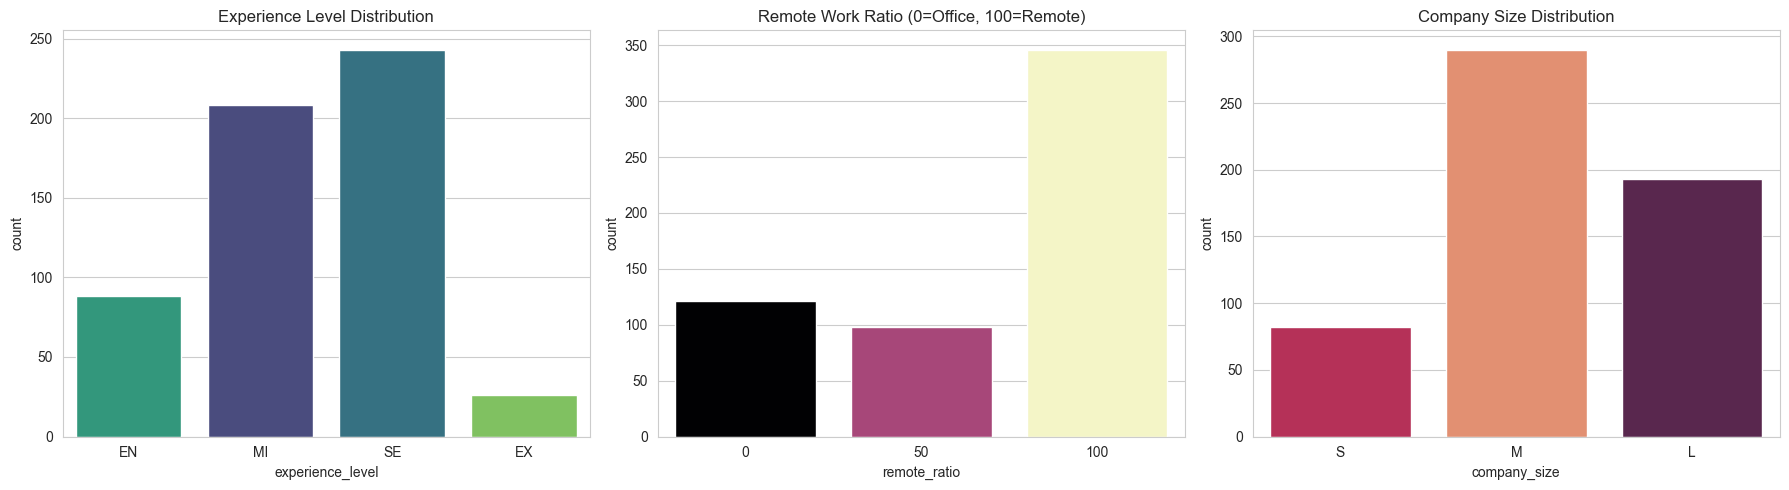

In [12]:
# Creating a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# subplot 1: Experience Level
sns.countplot(x='experience_level', hue='experience_level', data=df, 
              order=['EN', 'MI', 'SE', 'EX'], palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Experience Level Distribution')

# subplot 2: Remote Ratio
sns.countplot(x='remote_ratio', hue='remote_ratio', data=df, 
              palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Remote Work Ratio (0=Office, 100=Remote)')

# subplot 3: Company Size
sns.countplot(x='company_size', hue='company_size', data=df, 
              order=['S', 'M', 'L'], palette='rocket', legend=False, ax=axes[2])
axes[2].set_title('Company Size Distribution')

plt.tight_layout()
plt.show()

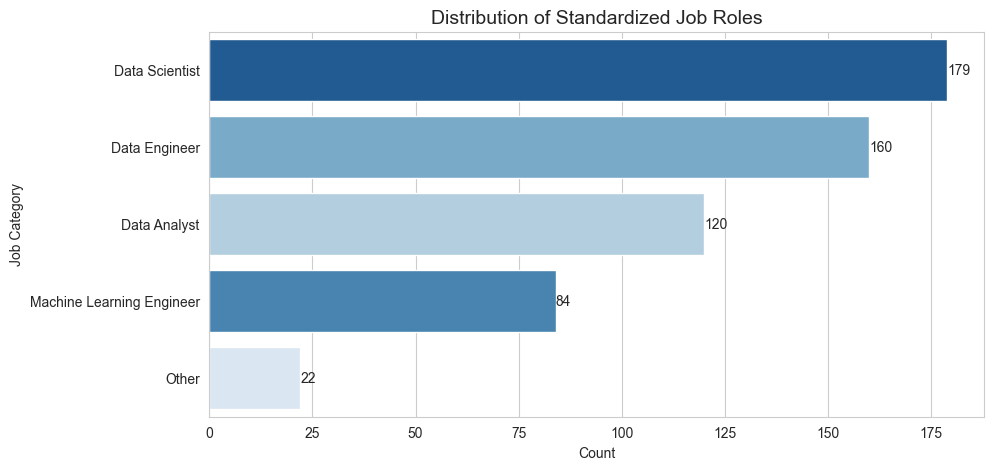

In [13]:
# Creating the figure 
fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(y='job_category', hue='job_category', data=df, 
              order=df['job_category'].value_counts().index, 
              palette='Blues_r', legend=False, ax=ax)

ax.set_title('Distribution of Standardized Job Roles', fontsize=14)
ax.set_xlabel('Count') 
ax.set_ylabel('Job Category')

for i in ax.containers:
    ax.bar_label(i)

plt.show()

In [ ]:
# notebook 3 end---